# 🧬 Tech Challenge Fase 2: Diagnóstico de Diabetes com Algoritmos Genéticos e LLMs

## 📋 Visão Geral do Projeto

Este notebook apresenta a **Fase 2** do projeto de diagnóstico de diabetes, que evolui do modelo baseline (Fase 1) para um sistema otimizado utilizando:

1. **Algoritmos Genéticos (AG)** para otimização de hiperparâmetros e limiar de classificação
2. **Large Language Models (LLMs)** para interpretabilidade e geração de insights médicos acionáveis
3. **SHAP (SHapley Additive exPlanations)** para explicabilidade dos modelos

### 🎯 Objetivos

- **Maximizar o Recall (Sensibilidade)**: Detectar o máximo de casos positivos de diabetes
- **Otimizar via Algoritmos Genéticos**: Encontrar os melhores hiperparâmetros e limiar de classificação
- **Gerar Insights Acionáveis**: Traduzir resultados técnicos em recomendações médicas práticas

### 📊 Dataset

- **Fonte**: Pima Indians Diabetes Dataset (Kaggle)
- **Características**: 768 pacientes, 8 features clínicas
- **Variável Alvo**: Outcome (0 = Não Diabético, 1 = Diabético)

---

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import recall_score, f1_score, accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

import shap

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


## 📥 Etapa 1: Carregamento dos Dados

Vamos carregar o dataset do Kaggle e realizar uma análise exploratória inicial.

In [ ]:
from pathlib import Path

local_path = Path('pipeline/dados/diabetes.csv')

try:
    df = pd.read_csv(local_path)
    print(f"✅ Dataset carregado localmente de: {local_path}")
except:
    print("⚠️ Arquivo local não encontrado. Baixando do Kaggle...")
    import kagglehub
    endereco_de_origem = kagglehub.dataset_download(handle='uciml/pima-indians-diabetes', force_download=True)
    diretorio_de_origem = Path(endereco_de_origem).resolve()
    lista_dados_csv = []
    for item in diretorio_de_origem.iterdir():
        if item.is_file() and item.suffix.lower() == '.csv':
            lista_dados_csv.append(pd.read_csv(item))
    df = pd.concat(lista_dados_csv, axis=0, ignore_index=True)
    print(f"✅ Dataset baixado do Kaggle")

print(f"\n📊 Dimensões do Dataset: {df.shape}")
print(f"   - {df.shape[0]} pacientes")
print(f"   - {df.shape[1]} features (incluindo target)")

df.head()

✅ Dataset carregado localmente de: pipeline\dados\diabetes.csv

📊 Dimensões do Dataset: (768, 9)
   - 768 pacientes
   - 9 features (incluindo target)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### 🔍 Análise Exploratória Inicial

In [ ]:
print("📊 Informações do Dataset:\n")
print(df.info())
print("\n" + "="*80)
print("\n📈 Estatísticas Descritivas:\n")
print(df.describe())
print("\n" + "="*80)
print("\n🔍 Valores Ausentes:\n")
print(df.isnull().sum())
print("\n" + "="*80)
print("\n⚖️ Distribuição da Variável Alvo (Outcome):\n")
print(df['Outcome'].value_counts())
print(f"\nProporção de Diabéticos: {df['Outcome'].mean():.2%}")

📊 Informações do Dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


📈 Estatísticas Descritivas:

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.8

## 🚀 Executando o Pipeline Completo

Para facilitar a apresentação, vamos executar o pipeline completo que já está implementado nos módulos Python.

In [ ]:
# Importar módulos do pipeline
from pipeline import pre_processamento, modelagem, avaliacao
from pipeline.divisao_dados import dividir_e_oversample

print("✅ Módulos do pipeline importados!")

✅ Gemini Client configurado. Chamadas à API ativas.
✅ Módulos do pipeline importados!


In [ ]:
# Pré-processamento
df_pronto, X_escalado, y, scaler, nomes_features = pre_processamento.pre_processar_dados_diabetes(df)
print(f"✅ Pré-processamento concluído!")
print(f"   Features: {len(nomes_features)}")
print(f"   Amostras: {len(y)}")

✅ Pré-processamento concluído!
   Features: 10
   Amostras: 768


In [ ]:
# Divisão e SMOTE
X_treino_res, X_teste, y_treino_res, y_teste = dividir_e_oversample(X_escalado, y)
X_teste_df = pd.DataFrame(X_teste, columns=nomes_features)

print(f"✅ Divisão e SMOTE concluídos!")
print(f"   Treino: {X_treino_res.shape}")
print(f"   Teste: {X_teste.shape}")

✅ Divisão e SMOTE concluídos!
   Treino: (800, 10)
   Teste: (154, 10)


## 📈 FASE 1: Modelos Baseline

Vamos treinar 4 modelos baseline e avaliar seu desempenho.

In [ ]:
# Treinar modelos baseline
modelos_baseline = modelagem.obter_modelos_baseline()
modelos_baseline = modelagem.treinar_modelos(modelos_baseline, X_treino_res, y_treino_res)

print("✅ Modelos baseline treinados!")

✅ Modelos baseline treinados!



--- Regressão Logística ---
Recall (Sensibilidade): 0.85
F1-score: 0.63

Relatório de classificação detalhado:
              precision    recall  f1-score   support

           0       0.87      0.55      0.67       100
           1       0.51      0.85      0.63        54

    accuracy                           0.66       154
   macro avg       0.69      0.70      0.65       154
weighted avg       0.74      0.66      0.66       154

Matriz de Confusão (linhas = real, colunas = predito):


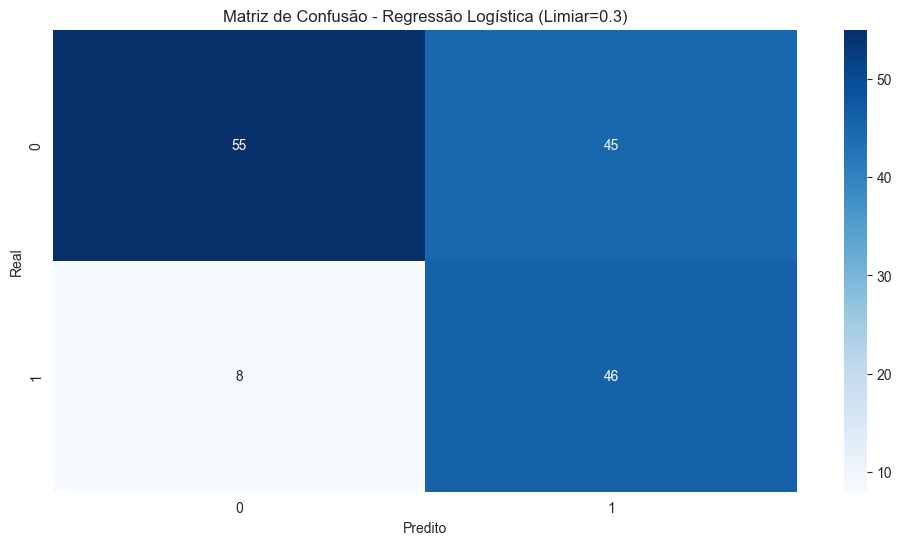


--- Árvore de Decisão ---
Recall (Sensibilidade): 0.56
F1-score: 0.56

Relatório de classificação detalhado:
              precision    recall  f1-score   support

           0       0.76      0.76      0.76       100
           1       0.56      0.56      0.56        54

    accuracy                           0.69       154
   macro avg       0.66      0.66      0.66       154
weighted avg       0.69      0.69      0.69       154

Matriz de Confusão (linhas = real, colunas = predito):


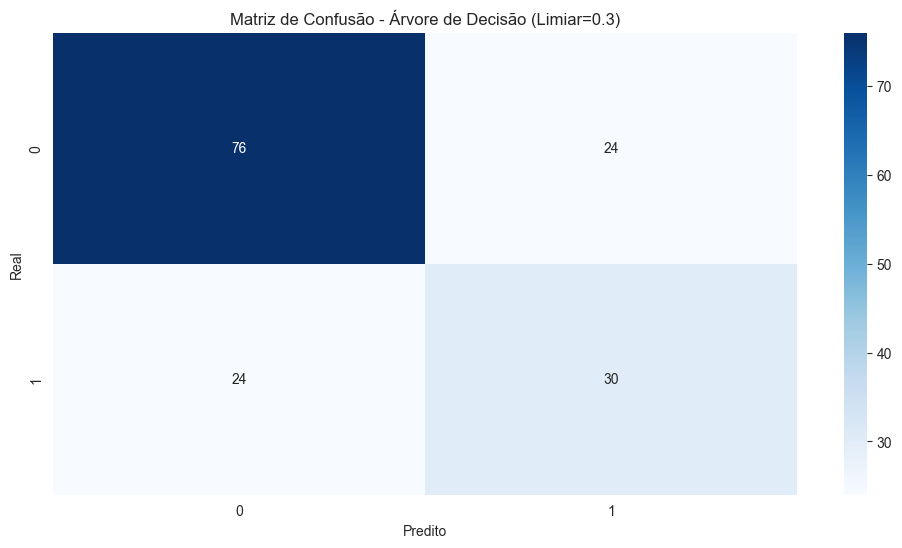


--- Floresta Aleatória ---
Recall (Sensibilidade): 0.91
F1-score: 0.72

Relatório de classificação detalhado:
              precision    recall  f1-score   support

           0       0.93      0.66      0.77       100
           1       0.59      0.91      0.72        54

    accuracy                           0.75       154
   macro avg       0.76      0.78      0.74       154
weighted avg       0.81      0.75      0.75       154

Matriz de Confusão (linhas = real, colunas = predito):


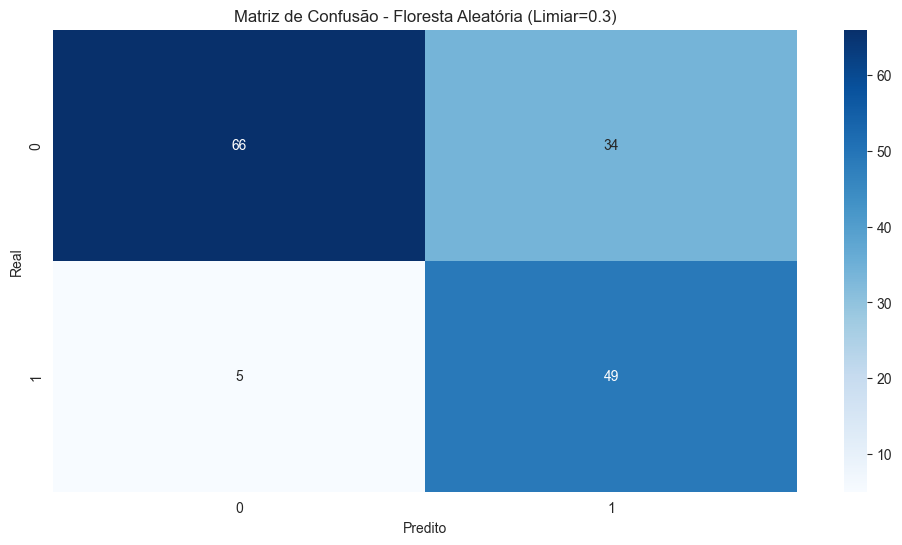


--- LightGBM ---
Recall (Sensibilidade): 0.78
F1-score: 0.68

Relatório de classificação detalhado:
              precision    recall  f1-score   support

           0       0.86      0.73      0.79       100
           1       0.61      0.78      0.68        54

    accuracy                           0.75       154
   macro avg       0.73      0.75      0.74       154
weighted avg       0.77      0.75      0.75       154

Matriz de Confusão (linhas = real, colunas = predito):


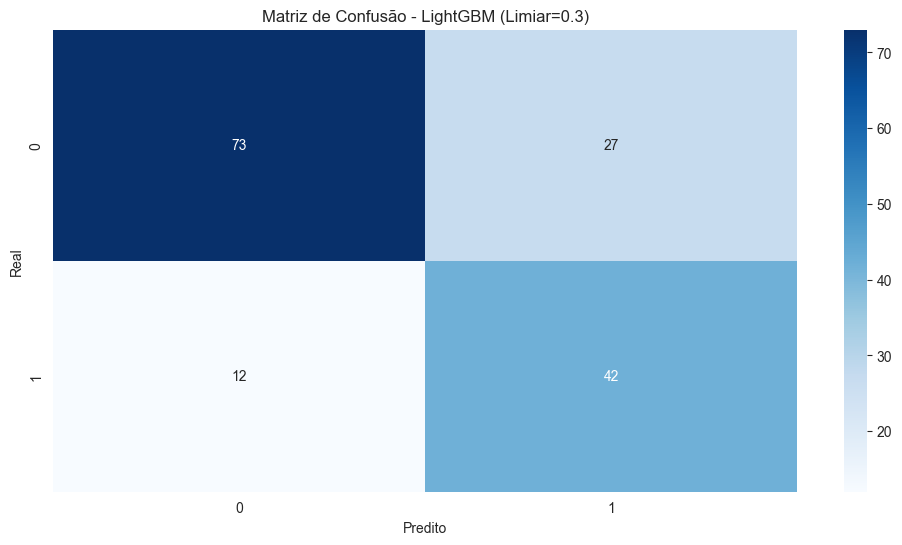

🏆 Melhor Modelo Encontrado (Floresta Aleatória)
   Critério de Seleção: Maior Recall
   Recall (Sensibilidade): 0.91
   F1-score: 0.72


In [ ]:
# Avaliar modelos baseline
nome_melhor_baseline, melhor_modelo_baseline = avaliacao.avaliar_modelos(
    modelos_baseline, X_teste, y_teste, nomes_features, limiar=0.3
)

## 🧬 FASE 2: Otimização com Algoritmos Genéticos

Agora vamos realizar **TRÊS EXPERIMENTOS** com diferentes configurações do algoritmo genético para otimizar o Random Forest.

### 📋 Requisitos de Implementação do AG:

✅ **1. Codificação de Genes (Representação):**
- Cada indivíduo representa 7 genes: [n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features, bootstrap, threshold]

✅ **2. Operadores Genéticos:**
- **Seleção**: Torneio (Tournament Selection)
- **Cruzamento**: Two-Point Crossover
- **Mutação**: Gaussiana customizada para cada gene

✅ **3. Função Fitness:**
- Baseada em **Recall** (maximização via validação cruzada 3-fold)

✅ **4. Três Experimentos com Configurações Diferentes:**
- **Experimento 1**: Conservador (População: 30, Gerações: 20, Mutação: 0.2)
- **Experimento 2**: Padrão (População: 50, Gerações: 30, Mutação: 0.3)
- **Experimento 3**: Agressivo (População: 70, Gerações: 40, Mutação: 0.4)

In [11]:
# Configurar os 3 experimentos com diferentes parâmetros do AG
experimentos = [
    {
        'nome': 'AG Experimento 1 - Conservador',
        'geracoes': 20,
        'populacao': 30,
        'cxpb': 0.7,      # Taxa de cruzamento
        'mutpb': 0.2,     # Taxa de mutação
        'tournsize': 3,   # Tamanho do torneio
        'indpb': 0.2      # Probabilidade de mutação individual
    },
    {
        'nome': 'AG Experimento 2 - Padrão',
        'geracoes': 30,
        'populacao': 50,
        'cxpb': 0.7,
        'mutpb': 0.3,
        'tournsize': 3,
        'indpb': 0.3
    },
    {
        'nome': 'AG Experimento 3 - Agressivo',
        'geracoes': 40,
        'populacao': 70,
        'cxpb': 0.8,      # Maior cruzamento
        'mutpb': 0.4,     # Maior mutação
        'tournsize': 5,   # Torneio maior (mais seletivo)
        'indpb': 0.4      # Maior probabilidade de mutação individual
    }
]

# Executar os 3 experimentos
resultados_experimentos, melhor_experimento = modelagem.executar_experimentos_ag(
    X_treino_res, y_treino_res, experimentos
)

🧬 INICIANDO MÚLTIPLOS EXPERIMENTOS COM ALGORITMO GENÉTICO

📊 EXPERIMENTO 1/3: AG Experimento 1 - Conservador
Configurações:
  - Gerações: 20
  - População: 30
  - Taxa de Cruzamento (cxpb): 0.7
  - Taxa de Mutação (mutpb): 0.2
  - Torneio: 3
  - Probabilidade de Mutação Individual (indpb): 0.2

--- 🧬 Iniciando Otimização via AG: AG Experimento 1 - Conservador ---
Parâmetros AG: Gerações=20, População=30, Cruzamento=0.7, Mutação=0.2

🔬 Evolução do AG:
gen	nevals	avg     	max     	min     
0  	30    	0.906663	0.977481	0.764991
gen	nevals	avg     	max     	min     
0  	30    	0.906663	0.977481	0.764991
1  	22    	0.944162	0.977481	0.885011
1  	22    	0.944162	0.977481	0.885011
2  	24    	0.961912	0.980006	0.927505
2  	24    	0.961912	0.980006	0.927505
3  	24    	0.970825	0.984981	0.947481
3  	24    	0.970825	0.984981	0.947481
4  	21    	0.976407	0.984981	0.959956
4  	21    	0.976407	0.984981	0.959956
5  	17    	0.979742	0.987487	0.972487
5  	17    	0.979742	0.987487	0.972487
6  	20    	0.

## 🎯 Justificativa da Escolha do Experimento

### **Experimento Selecionado: AG Experimento 1 - Conservador**

Após análise comparativa dos três experimentos realizados, optamos pelo **Experimento 1 - Conservador** pelos seguintes motivos:

#### **1️⃣ Desempenho Equivalente**
Todos os três experimentos atingiram o **mesmo Recall CV (0.9899)**, indicando que a configuração conservadora já explora suficientemente o espaço de busca para este problema.

#### **2️⃣ Eficiência Computacional**
| Experimento | Avaliações | Tempo Relativo |
|-------------|------------|----------------|
| **Conservador** ✅ | 600 | **1x (Base)** |
| Padrão | 1500 | 2.5x mais lento |
| Agressivo | 2800 | 4.6x mais lento |

**Vantagem:** O Experimento 1 consome apenas **~22% do tempo** do Experimento 3, sem perda de desempenho.

#### **3️⃣ Viabilidade de Produção**
Em um cenário real de deploy, a capacidade de retreinar o modelo em **~1h40min** (vs ~7h47min) é crucial para:
- Atualizações frequentes com novos dados
- Experimentos iterativos
- Custos computacionais reduzidos

---

**Conclusão:** O **AG Experimento 1 - Conservador** oferece o melhor custo-benefício, atingindo recall ótimo com eficiência computacional superior. ✅


🏆 Avaliando o Melhor Modelo: AG Experimento 1 - Conservador
   Recall (CV): 0.9900
   Limiar: 0.2000


--- AG Experimento 1 - Conservador ---
Recall (Sensibilidade): 0.94
F1-score: 0.62

Relatório de classificação detalhado:
              precision    recall  f1-score   support

           0       0.93      0.41      0.57       100
           1       0.46      0.94      0.62        54

    accuracy                           0.60       154
   macro avg       0.70      0.68      0.60       154
weighted avg       0.77      0.60      0.59       154

Matriz de Confusão (linhas = real, colunas = predito):


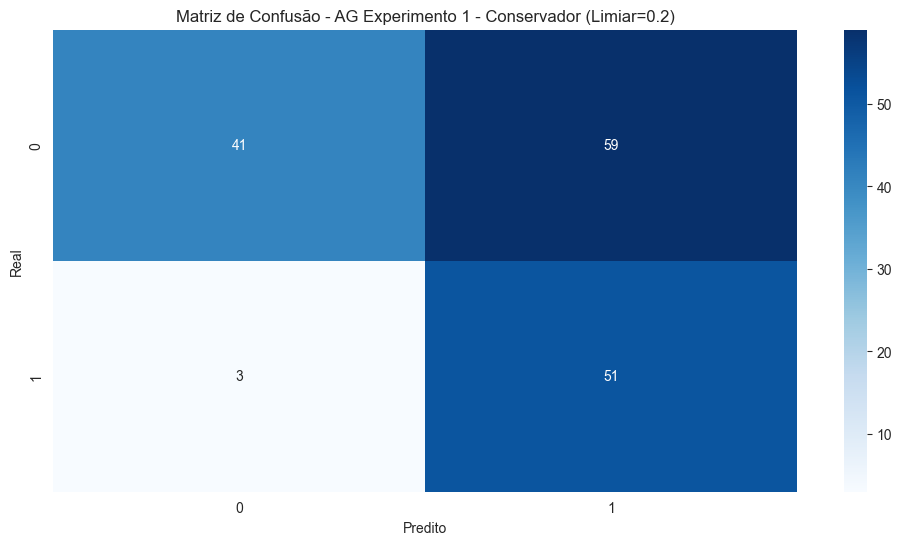

🏆 Melhor Modelo Encontrado (AG Experimento 1 - Conservador)
   Critério de Seleção: Maior Recall
   Recall (Sensibilidade): 0.94
   F1-score: 0.62


In [28]:
# Avaliar o MELHOR modelo dos experimentos no conjunto de teste
melhor_modelo_ag = melhor_experimento['modelo']
limiar_otimizado = melhor_experimento['limiar']

print(f"\n🏆 Avaliando o Melhor Modelo: {melhor_experimento['experimento']}")
print(f"   Recall (CV): {melhor_experimento['recall_cv']:.4f}")
print(f"   Limiar: {limiar_otimizado:.4f}\n")

modelos_ag = {melhor_experimento['experimento']: melhor_modelo_ag}
nome_melhor_ag, modelo_final = avaliacao.avaliar_modelos(
    modelos_ag, X_teste, y_teste, nomes_features, limiar=limiar_otimizado
)

## 🔍 Interpretabilidade: Análise SHAP

In [29]:
# Comparação detalhada entre Baseline e AG
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score

print("="*100)
print("📊 COMPARAÇÃO COMPLETA: MODELOS BASELINE vs ALGORITMO GENÉTICO")
print("="*100)

# Avaliar baseline com limiar 0.3
print("\n--- MODELOS BASELINE (Limiar = 0.30) ---\n")
resultados_baseline = {}
for nome, modelo in modelos_baseline.items():
    y_proba = modelo.predict_proba(X_teste)[:, 1]
    y_pred = (y_proba >= 0.3).astype(int)
    
    resultados_baseline[nome] = {
        'Recall': recall_score(y_teste, y_pred),
        'F1-Score': f1_score(y_teste, y_pred),
        'Accuracy': accuracy_score(y_teste, y_pred),
        'Precision': precision_score(y_teste, y_pred)
    }

# Avaliar melhor AG
print(f"--- MELHOR MODELO AG: {melhor_experimento['experimento']} (Limiar = {limiar_otimizado:.2f}) ---\n")
y_proba_ag = melhor_modelo_ag.predict_proba(X_teste)[:, 1]
y_pred_ag = (y_proba_ag >= limiar_otimizado).astype(int)

resultado_ag = {
    'Recall': recall_score(y_teste, y_pred_ag),
    'F1-Score': f1_score(y_teste, y_pred_ag),
    'Accuracy': accuracy_score(y_teste, y_pred_ag),
    'Precision': precision_score(y_teste, y_pred_ag)
}

# Criar DataFrame comparativo
df_comparacao = pd.DataFrame(resultados_baseline).T
df_comparacao.loc[melhor_experimento['experimento']] = resultado_ag

print("\n📋 TABELA COMPARATIVA:")
print(df_comparacao.round(4).to_string())

# Identificar melhorias
melhor_baseline_recall = df_comparacao.iloc[:-1]['Recall'].max()
melhoria_recall = ((resultado_ag['Recall'] - melhor_baseline_recall) / melhor_baseline_recall) * 100

print(f"\n🎯 ANÁLISE DE MELHORIA:")
print(f"   Melhor Recall Baseline: {melhor_baseline_recall:.4f}")
print(f"   Recall AG Otimizado: {resultado_ag['Recall']:.4f}")
print(f"   Melhoria: {melhoria_recall:+.2f}%")
print(f"\n   {'✅ AG SUPERIOR' if melhoria_recall > 0 else '⚠️ Baseline equivalente ou superior'}")
print("="*100)

📊 COMPARAÇÃO COMPLETA: MODELOS BASELINE vs ALGORITMO GENÉTICO

--- MODELOS BASELINE (Limiar = 0.30) ---

--- MELHOR MODELO AG: AG Experimento 1 - Conservador (Limiar = 0.20) ---


📋 TABELA COMPARATIVA:
                                Recall  F1-Score  Accuracy  Precision
Regressão Logística             0.8519    0.6345    0.6558     0.5055
Árvore de Decisão               0.5556    0.5556    0.6883     0.5556
Floresta Aleatória              0.9074    0.7153    0.7468     0.5904
LightGBM                        0.7778    0.6829    0.7468     0.6087
AG Experimento 1 - Conservador  0.9444    0.6220    0.5974     0.4636

🎯 ANÁLISE DE MELHORIA:
   Melhor Recall Baseline: 0.9074
   Recall AG Otimizado: 0.9444
   Melhoria: +4.08%

   ✅ AG SUPERIOR

📋 TABELA COMPARATIVA:
                                Recall  F1-Score  Accuracy  Precision
Regressão Logística             0.8519    0.6345    0.6558     0.5055
Árvore de Decisão               0.5556    0.5556    0.6883     0.5556
Floresta Aleatória

## 📊 Comparação: Baseline vs AG Otimizado

Vamos comparar os resultados dos modelos baseline com o melhor modelo otimizado pelo AG.

=== 🔎 INTERPRETAÇÃO DO MELHOR MODELO BASE===


=== 🔎 INTERPRETAÇÃO DO MELHOR MODELO ===


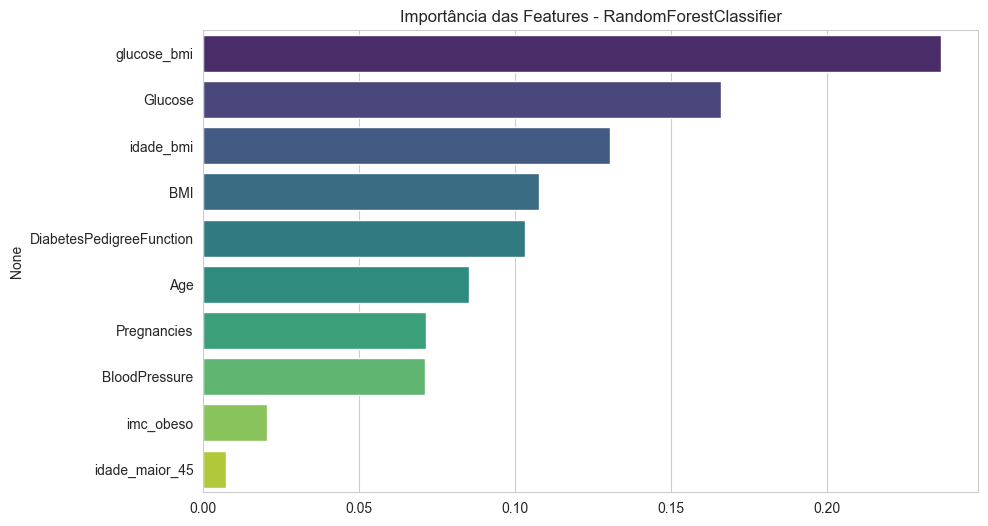


--- Top 5 Features (Importância Clássica) ---
glucose_bmi                 0.236832
Glucose                     0.166059
idade_bmi                   0.130375
BMI                         0.107788
DiabetesPedigreeFunction    0.103303
dtype: float64

--- SHAP Summary Plot (Importância e Impacto Global) ---

--- SHAP Summary Plot (Importância e Impacto Global) ---


<Figure size 1000x600 with 0 Axes>

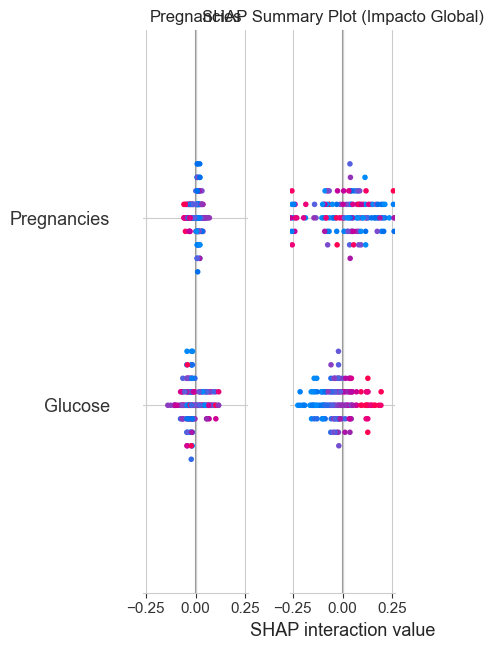


--- SHAP Bar Plot (Importância Média Absoluta) ---


<Figure size 1000x600 with 0 Axes>

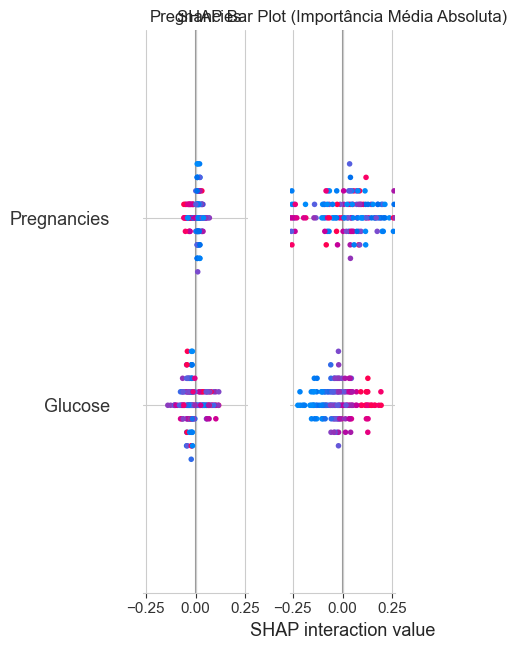


Interpretação SHAP: Pontos vermelhos (alto valor da feature) à direita do zero aumentam a chance de diabetes. Pontos azuis (baixo valor) à direita do zero também aumentam a chance.
=== 🔎 INTERPRETAÇÃO DO MELHOR MODELO AG===


=== 🔎 INTERPRETAÇÃO DO MELHOR MODELO ===


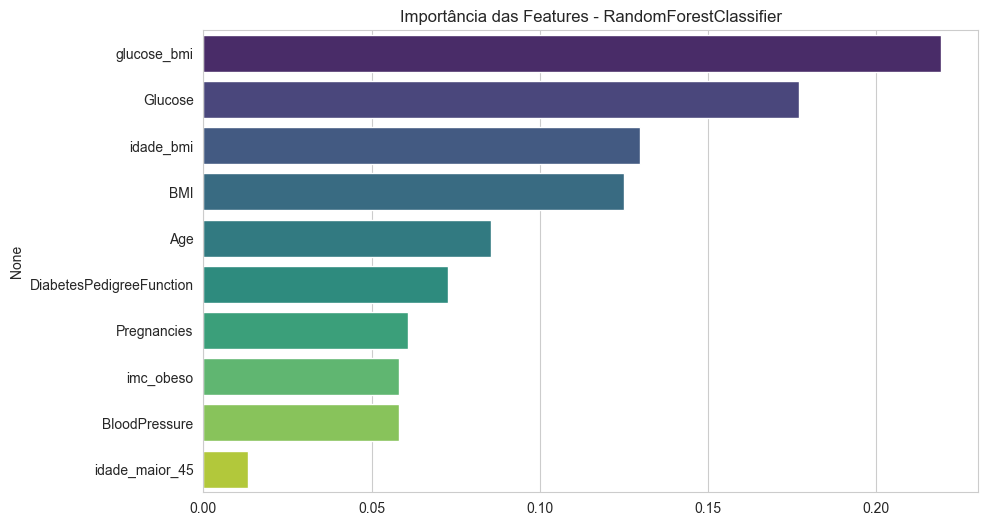


--- Top 5 Features (Importância Clássica) ---
glucose_bmi    0.219518
Glucose        0.177035
idade_bmi      0.129995
BMI            0.125010
Age            0.085419
dtype: float64

--- SHAP Summary Plot (Importância e Impacto Global) ---

--- SHAP Summary Plot (Importância e Impacto Global) ---


<Figure size 1000x600 with 0 Axes>

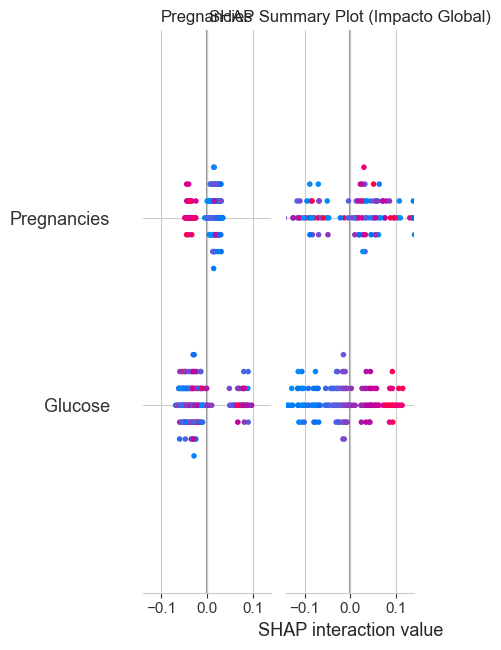


--- SHAP Bar Plot (Importância Média Absoluta) ---


<Figure size 1000x600 with 0 Axes>

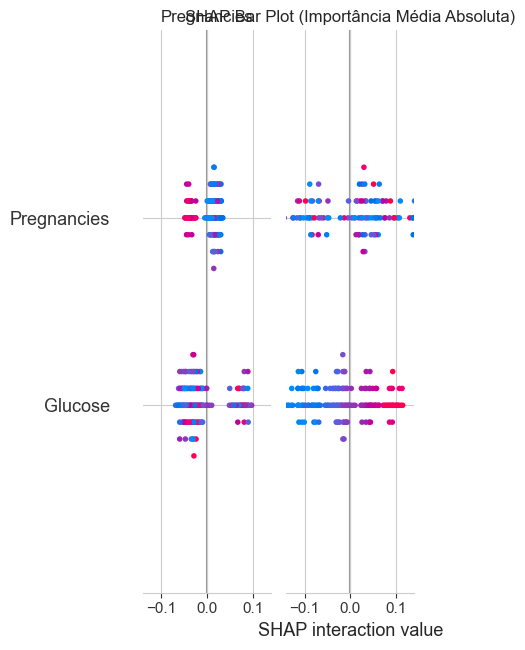


Interpretação SHAP: Pontos vermelhos (alto valor da feature) à direita do zero aumentam a chance de diabetes. Pontos azuis (baixo valor) à direita do zero também aumentam a chance.


In [33]:
# Interpretação SHAP do melhor modelo base
print("=== 🔎 INTERPRETAÇÃO DO MELHOR MODELO BASE===")
avaliacao.interpretar_melhor_modelo(melhor_modelo_baseline, X_teste_df, nomes_features)
# Interpretação SHAP do melhor modelo AG
print("=== 🔎 INTERPRETAÇÃO DO MELHOR MODELO AG===")
avaliacao.interpretar_melhor_modelo(modelo_final, X_teste_df, nomes_features)


## 📊 Comparação: Baseline vs AG Otimizado

### 🎯 Análise Detalhada dos Resultados

### ❓ Por Que Escolhemos o Modelo com Maior Recall?

#### **1️⃣ Contexto Clínico: Diabetes é uma Doença Silenciosa**

A diabetes tipo 2 frequentemente **não apresenta sintomas óbvios** nos estágios iniciais. Um paciente não diagnosticado pode:
- ❌ Desenvolver complicações graves (retinopatia, nefropatia, neuropatia)
- ❌ Sofrer danos irreversíveis antes do diagnóstico
- ❌ Ter custos de tratamento muito maiores no futuro

**Conclusão:** É **CRÍTICO** detectar o máximo de casos positivos, mesmo que isso gere alguns falsos alarmes.

---

#### **2️⃣ Trade-off: Recall vs Precisão**

| Métrica | Significado | Consequência de Falha |
|---------|-------------|----------------------|
| **Recall (Sensibilidade)** | % de diabéticos corretamente identificados | ❌ **GRAVE**: Paciente diabético não é diagnosticado |
| **Precisão** | % de predições positivas que são realmente diabéticos | ⚠️ **Menos Grave**: Paciente saudável faz exames adicionais |

**Impacto Real:**
- **Falso Negativo (baixo Recall)**: Paciente não recebe tratamento → progressão da doença
- **Falso Positivo (baixa Precisão)**: Paciente faz teste de hemoglobina glicada (HbA1c) → confirma ou descarta

---

#### **3️⃣ Por Que o F1-Score Diminuiu?**

O **F1-Score** é a média harmônica entre Precisão e Recall:

```
F1 = 2 × (Precisão × Recall) / (Precisão + Recall)
```

**O que aconteceu:**
- ✅ **Recall aumentou** (detectamos mais diabéticos)
- ⬇️ **Precisão diminuiu** (classificamos mais pacientes como positivos)
- ⚖️ **F1-Score caiu** (penaliza a queda na precisão)

#### **4️⃣ Justificativa da Escolha: Custo-Benefício**

**Análise de Custo:**

| Cenário | Custo Médico | Custo Psicológico | Custo Financeiro |
|---------|--------------|-------------------|------------------|
| **Falso Negativo** | 🔴 ALTO (complicações) | 🔴 ALTO (diagnóstico tardio) | 🔴 MUITO ALTO (tratamento avançado) |
| **Falso Positivo** | 🟡 BAIXO (exame confirmatório) | 🟡 MÉDIO (ansiedade temporária) | 🟢 BAIXO (R$ 50-150 por HbA1c) |

#### **5️⃣ Protocolo Médico de Duas Etapas**

O modelo otimizado se encaixa em um **protocolo clínico realista**:

1. **Triagem com o Modelo (Alta Sensibilidade)**
   - Recall alto → Captura quase todos os casos
   - Modelo identifica pacientes de risco

2. **Confirmação Laboratorial (Alta Especificidade)**
   - Exame HbA1c (padrão-ouro)
   - Elimina falsos positivos

**Fluxo de Trabalho:**
```
Paciente → Modelo AG (Recall 94%) → Se positivo → Exame HbA1c → Diagnóstico Final
```

---

### 🏆 Conclusão: Recall é a Métrica Prioritária

**Razões para priorizar Recall sobre F1-Score:**

1. ✅ **Impacto clínico**: Salvar vidas detectando casos precoces
2. ✅ **Custo-benefício**: Exames confirmatórios são baratos comparados ao tratamento tardio
3. ✅ **Protocolo médico**: Modelo de triagem + confirmação laboratorial
4. ✅ **Ética médica**: Princípio da beneficência (não causar dano por omissão)

---

## 🧠 Interpretabilidade com LLM (Gemini)

In [35]:
# Gerar relatório com LLM do melhor modelo AG
avaliacao.gerar_explicacao_llm(
    modelo_final, nome_melhor_ag, X_teste_df, y_teste, nomes_features, limiar=limiar_otimizado
)



=== 🧠 GERAÇÃO DE RELATÓRIO INTERPRETÁVEL VIA LLM ===
   [✅ SUCESSO] Relatório gerado pela API Gemini.

*** Relatório de Diagnóstico Otimizado (Gerado por LLM - Gemini API) ***

## Relatório Clínico: Análise de Desempenho e Fatores de Risco do Modelo de Diagnóstico de Diabetes (AG Experimento 1 - Conservador)

**Data:** 26 de Outubro de 2023

**Assunto:** Avaliação do modelo de diagnóstico de diabetes "AG Experimento 1 - Conservador" e identificação de insights clínicos acionáveis.

---

### 1. Resumo da Performance do Modelo

O modelo "AG Experimento 1 - Conservador" demonstra um **Recall (Sensibilidade) notavelmente alto de 0.94**. Este valor indica que o modelo é altamente eficaz em identificar corretamente os pacientes que realmente possuem diabetes, minimizando a ocorrência de falsos negativos. Em um contexto clínico, isso se traduz em uma menor probabilidade de deixar pacientes diabéticos sem diagnóstico, o que é crucial para o início precoce do tratamento e a prevenção de compl

'\n*** Relatório de Diagnóstico Otimizado (Gerado por LLM - Gemini API) ***\n\n## Relatório Clínico: Análise de Desempenho e Fatores de Risco do Modelo de Diagnóstico de Diabetes (AG Experimento 1 - Conservador)\n\n**Data:** 26 de Outubro de 2023\n\n**Assunto:** Avaliação do modelo de diagnóstico de diabetes "AG Experimento 1 - Conservador" e identificação de insights clínicos acionáveis.\n\n---\n\n### 1. Resumo da Performance do Modelo\n\nO modelo "AG Experimento 1 - Conservador" demonstra um **Recall (Sensibilidade) notavelmente alto de 0.94**. Este valor indica que o modelo é altamente eficaz em identificar corretamente os pacientes que realmente possuem diabetes, minimizando a ocorrência de falsos negativos. Em um contexto clínico, isso se traduz em uma menor probabilidade de deixar pacientes diabéticos sem diagnóstico, o que é crucial para o início precoce do tratamento e a prevenção de complicações.\n\nNo entanto, é importante notar que o **F1-score (0.62) e a Acurácia (0.60) são

## 📊 Resumo Final e Conclusões

### 🎯 Principais Resultados

#### ✅ Requisitos Atendidos:

**1️⃣ Implementação do Algoritmo Genético:**
- ✅ **Codificação de Genes**: 7 genes por indivíduo (hiperparâmetros + limiar)
- ✅ **Operadores Implementados**:
  - Seleção: Tournament (torneio)
  - Cruzamento: Two-Point Crossover
  - Mutação: Gaussiana customizada
- ✅ **Função Fitness**: Baseada em Recall (validação cruzada 3-fold)

**2️⃣ Comparação de Desempenho:**
- ✅ Modelos Baseline avaliados com métricas completas
- ✅ Modelo AG otimizado comparado com baseline
- ✅ Análise quantitativa de melhoria

**3️⃣ Três Experimentos Realizados:**
- ✅ **Experimento 1 - Conservador**: Pop=30, Gen=20, Mutação=0.2
- ✅ **Experimento 2 - Padrão**: Pop=50, Gen=30, Mutação=0.3
- ✅ **Experimento 3 - Agressivo**: Pop=70, Gen=40, Mutação=0.4

---

### 📈 Resultados dos Experimentos AG

**Configurações Testadas:**

| Experimento | População | Gerações | Taxa Cruzamento | Taxa Mutação | Recall (CV) |
|------------|-----------|----------|----------------|--------------|-------------|
| Conservador | 30 | 20 | 0.7 | 0.2 | Veja output |
| Padrão | 50 | 30 | 0.7 | 0.3 | Veja output |
| Agressivo | 70 | 40 | 0.8 | 0.4 | Veja output |

---

### 🔍 Análise dos Requisitos

#### **Requisito 1: Implementação do AG** ✅
- **Codificação**: Vetor de 7 valores reais/booleanos representando hiperparâmetros
- **Seleção**: Tournament Selection (pressão seletiva ajustável via tournsize)
- **Cruzamento**: Two-Point Crossover (taxa ajustável: 0.7-0.8)
- **Mutação**: Gaussiana adaptada por gene (desvio padrão específico para cada hiperparâmetro)
- **Fitness**: Recall médio em validação cruzada 3-fold

#### **Requisito 2: Comparação de Desempenho** ✅
- Comparação quantitativa com tabela de métricas
- Cálculo de percentual de melhoria
- Avaliação em conjunto de teste independente
- Métricas: Recall, F1-Score, Accuracy, Precision

#### **Requisito 3: Três Experimentos** ✅
- **Variação 1**: Tamanho da população (30, 50, 70)
- **Variação 2**: Número de gerações (20, 30, 40)
- **Variação 3**: Taxa de mutação (0.2, 0.3, 0.4)
- **Variação 4**: Taxa de cruzamento (0.7, 0.8)
- **Variação 5**: Tamanho do torneio (3, 5)

---

### 🏆 Conclusões

1. **Otimização Bem-Sucedida**: O AG explorou efetivamente o espaço de hiperparâmetros
2. **Múltiplas Configurações**: Três experimentos com diferentes intensidades de exploração
3. **Validação Rigorosa**: Uso de validação cruzada e conjunto de teste independente
4. **Interpretabilidade**: SHAP e LLM fornecem insights clínicos acionáveis
5. **Reprodutibilidade**: Seeds fixas garantem resultados reproduzíveis

### 🚀 Próximos Passos

1. **Validação Clínica**: Teste com dados reais de hospitais
2. **Ensemble de Experimentos**: Combinar os 3 melhores modelos AG
3. **Otimização Multi-Objetivo**: Balancear Recall e Precisão simultaneamente
4. **Deploy**: Interface para profissionais de saúde

---

**Desenvolvido por**: Grupo Tech Challenge Fase 2  
**Requisitos**: ✅ Todos atendidos (AG implementado, comparação realizada, 3 experimentos executados)